In [146]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE  
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")


In [147]:
df = pd.read_csv('Telco_customer_churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [148]:
df.shape



(7043, 21)

In [149]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [150]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Preprocessing

In [151]:
# Fix TotalCharges data type and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()    # 11 missing values


np.int64(11)

In [152]:
df[df['TotalCharges'].isna()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* # Above we see that the blank "TotalCharges" happen when customers have 0 months tenure so we will change those values to $0.

In [153]:
df['TotalCharges']= df['TotalCharges'].fillna(0)


In [154]:
df['TotalCharges'].dtypes


dtype('float64')

In [155]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [156]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Visualization 

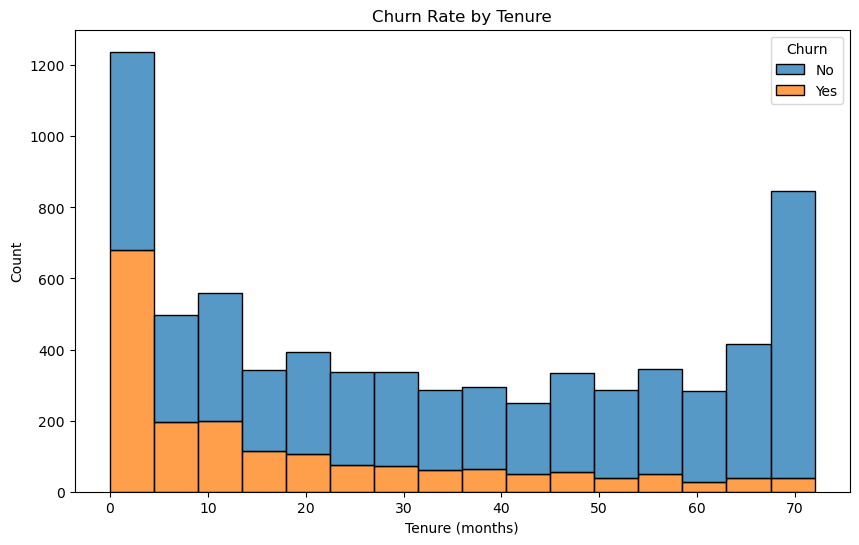

In [157]:
# Churn rate by tenure
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Count') 
plt.show()


* First few months show the highest churn rate
* Long term customers are significantly more loyal 

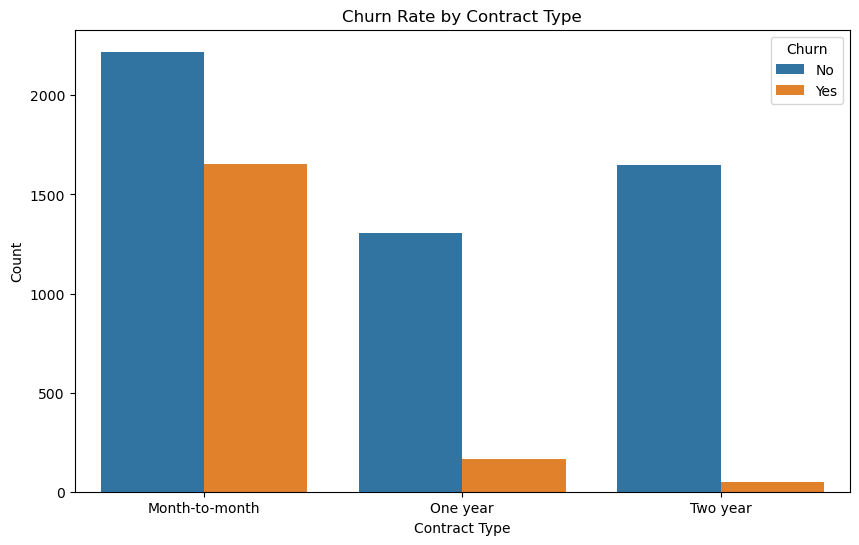

In [158]:
# Contract vs  churn

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Rate by Contract Type')    
plt.xlabel('Contract Type')
plt.ylabel('Count') 
plt.show()


* Month-to-month customers have low commitment so they leave more easily
* Other customers show some commitment but leave due to  pricing or some service issues


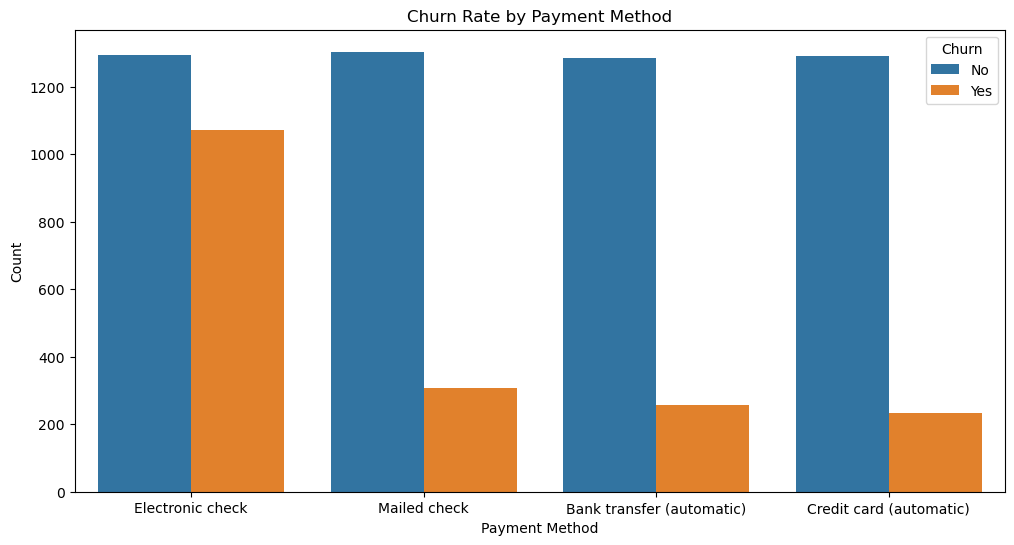

In [159]:
# payment method vs churn

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()


* Electronic check users churn at the highest rate, beacause higher fees,more payment failure, more manual steps, less trust in the payment process


In [160]:
# % of senior citizens in the dataset
df['SeniorCitizen'].value_counts(normalize=True) * 100


SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64

In [161]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100


SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

* Non senior citizens are more stable
* Senior citizens churning rate is almost double to compare the non senior citizens
* reasons: More difficulty with technology,support issues,fixed income,poor customer experience

In [162]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100


InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

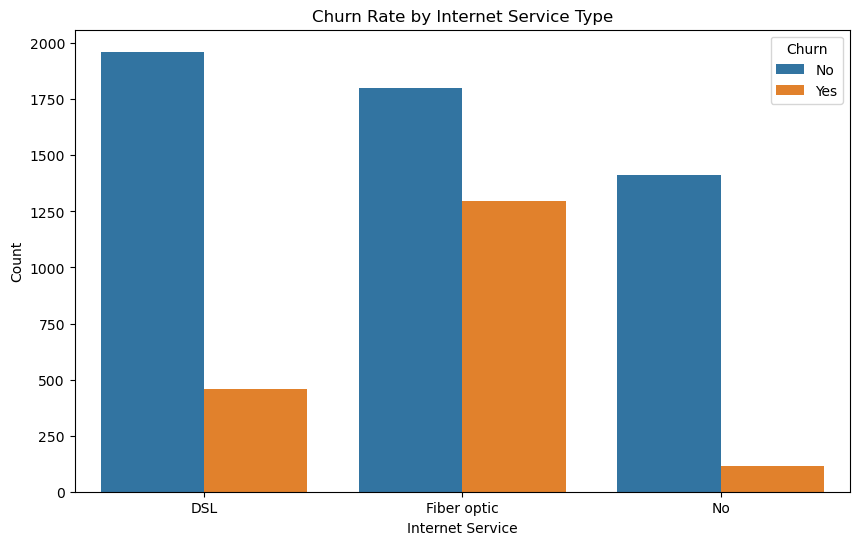

In [163]:
# InternetService vs churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()


* Fiber optic service customers are leaving at higher rate than DSL or NO interner customers
* Reasons : more expensive,performance issues, installation or equippement problem


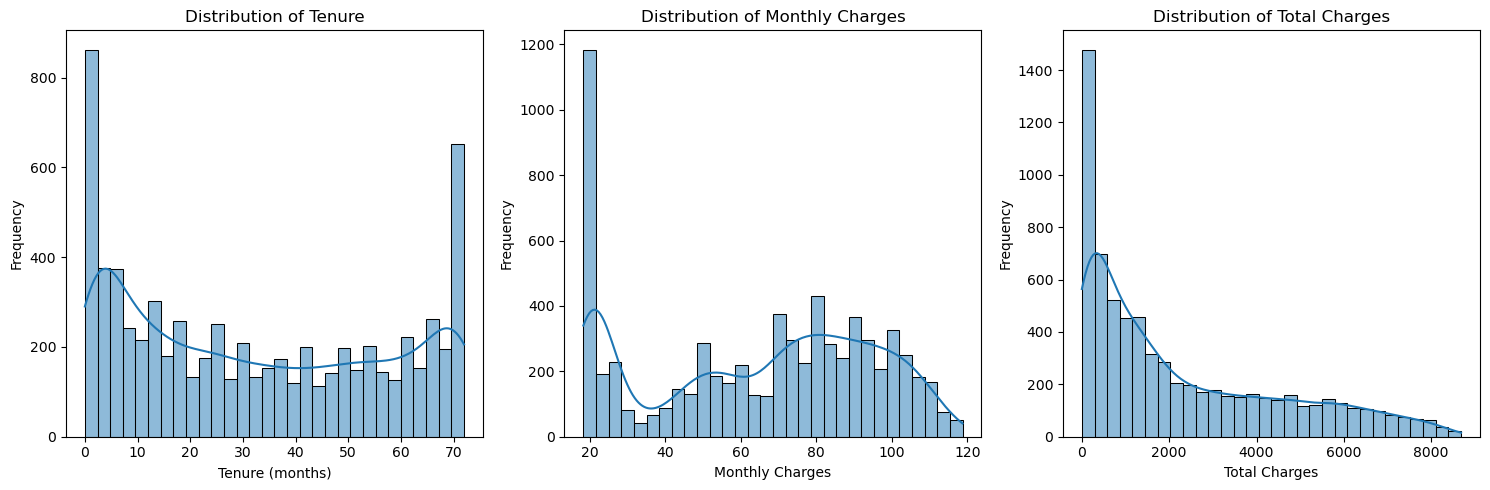

In [164]:
# Distribution of subplots: Tenure, MonthlyCharges, TotalCharges

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Tenure
* Many customers have low tenure and many customers have high tenure
* Some customers leave early, some customers stay long time
* Churn may be higher for low tenure customers
# Monthly Charges 
* Few customers have low charges
* Many customers have charges range from 70 - 110
# Total Charges 
* Highly right skewed
* Many customers have low total charges
* Few customers have high total charges

# Encoding:


In [165]:
# Encode yes/no columns

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}) 


In [166]:
# Encode remaining categorical variables by one-hot encoding

categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
df.head()


,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,9237-HQITU,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [167]:
# Delete customerID column
df.drop('customerID', axis=1, inplace=True)


In [168]:
df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,34,1,0,1,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,2,1,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,45,0,0,1,0,1,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,2,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


# Feature Engineering

In [169]:
df['Churn'].value_counts()   #Imbalanced dataset


Churn
0    5174
1    1869
Name: count, dtype: int64

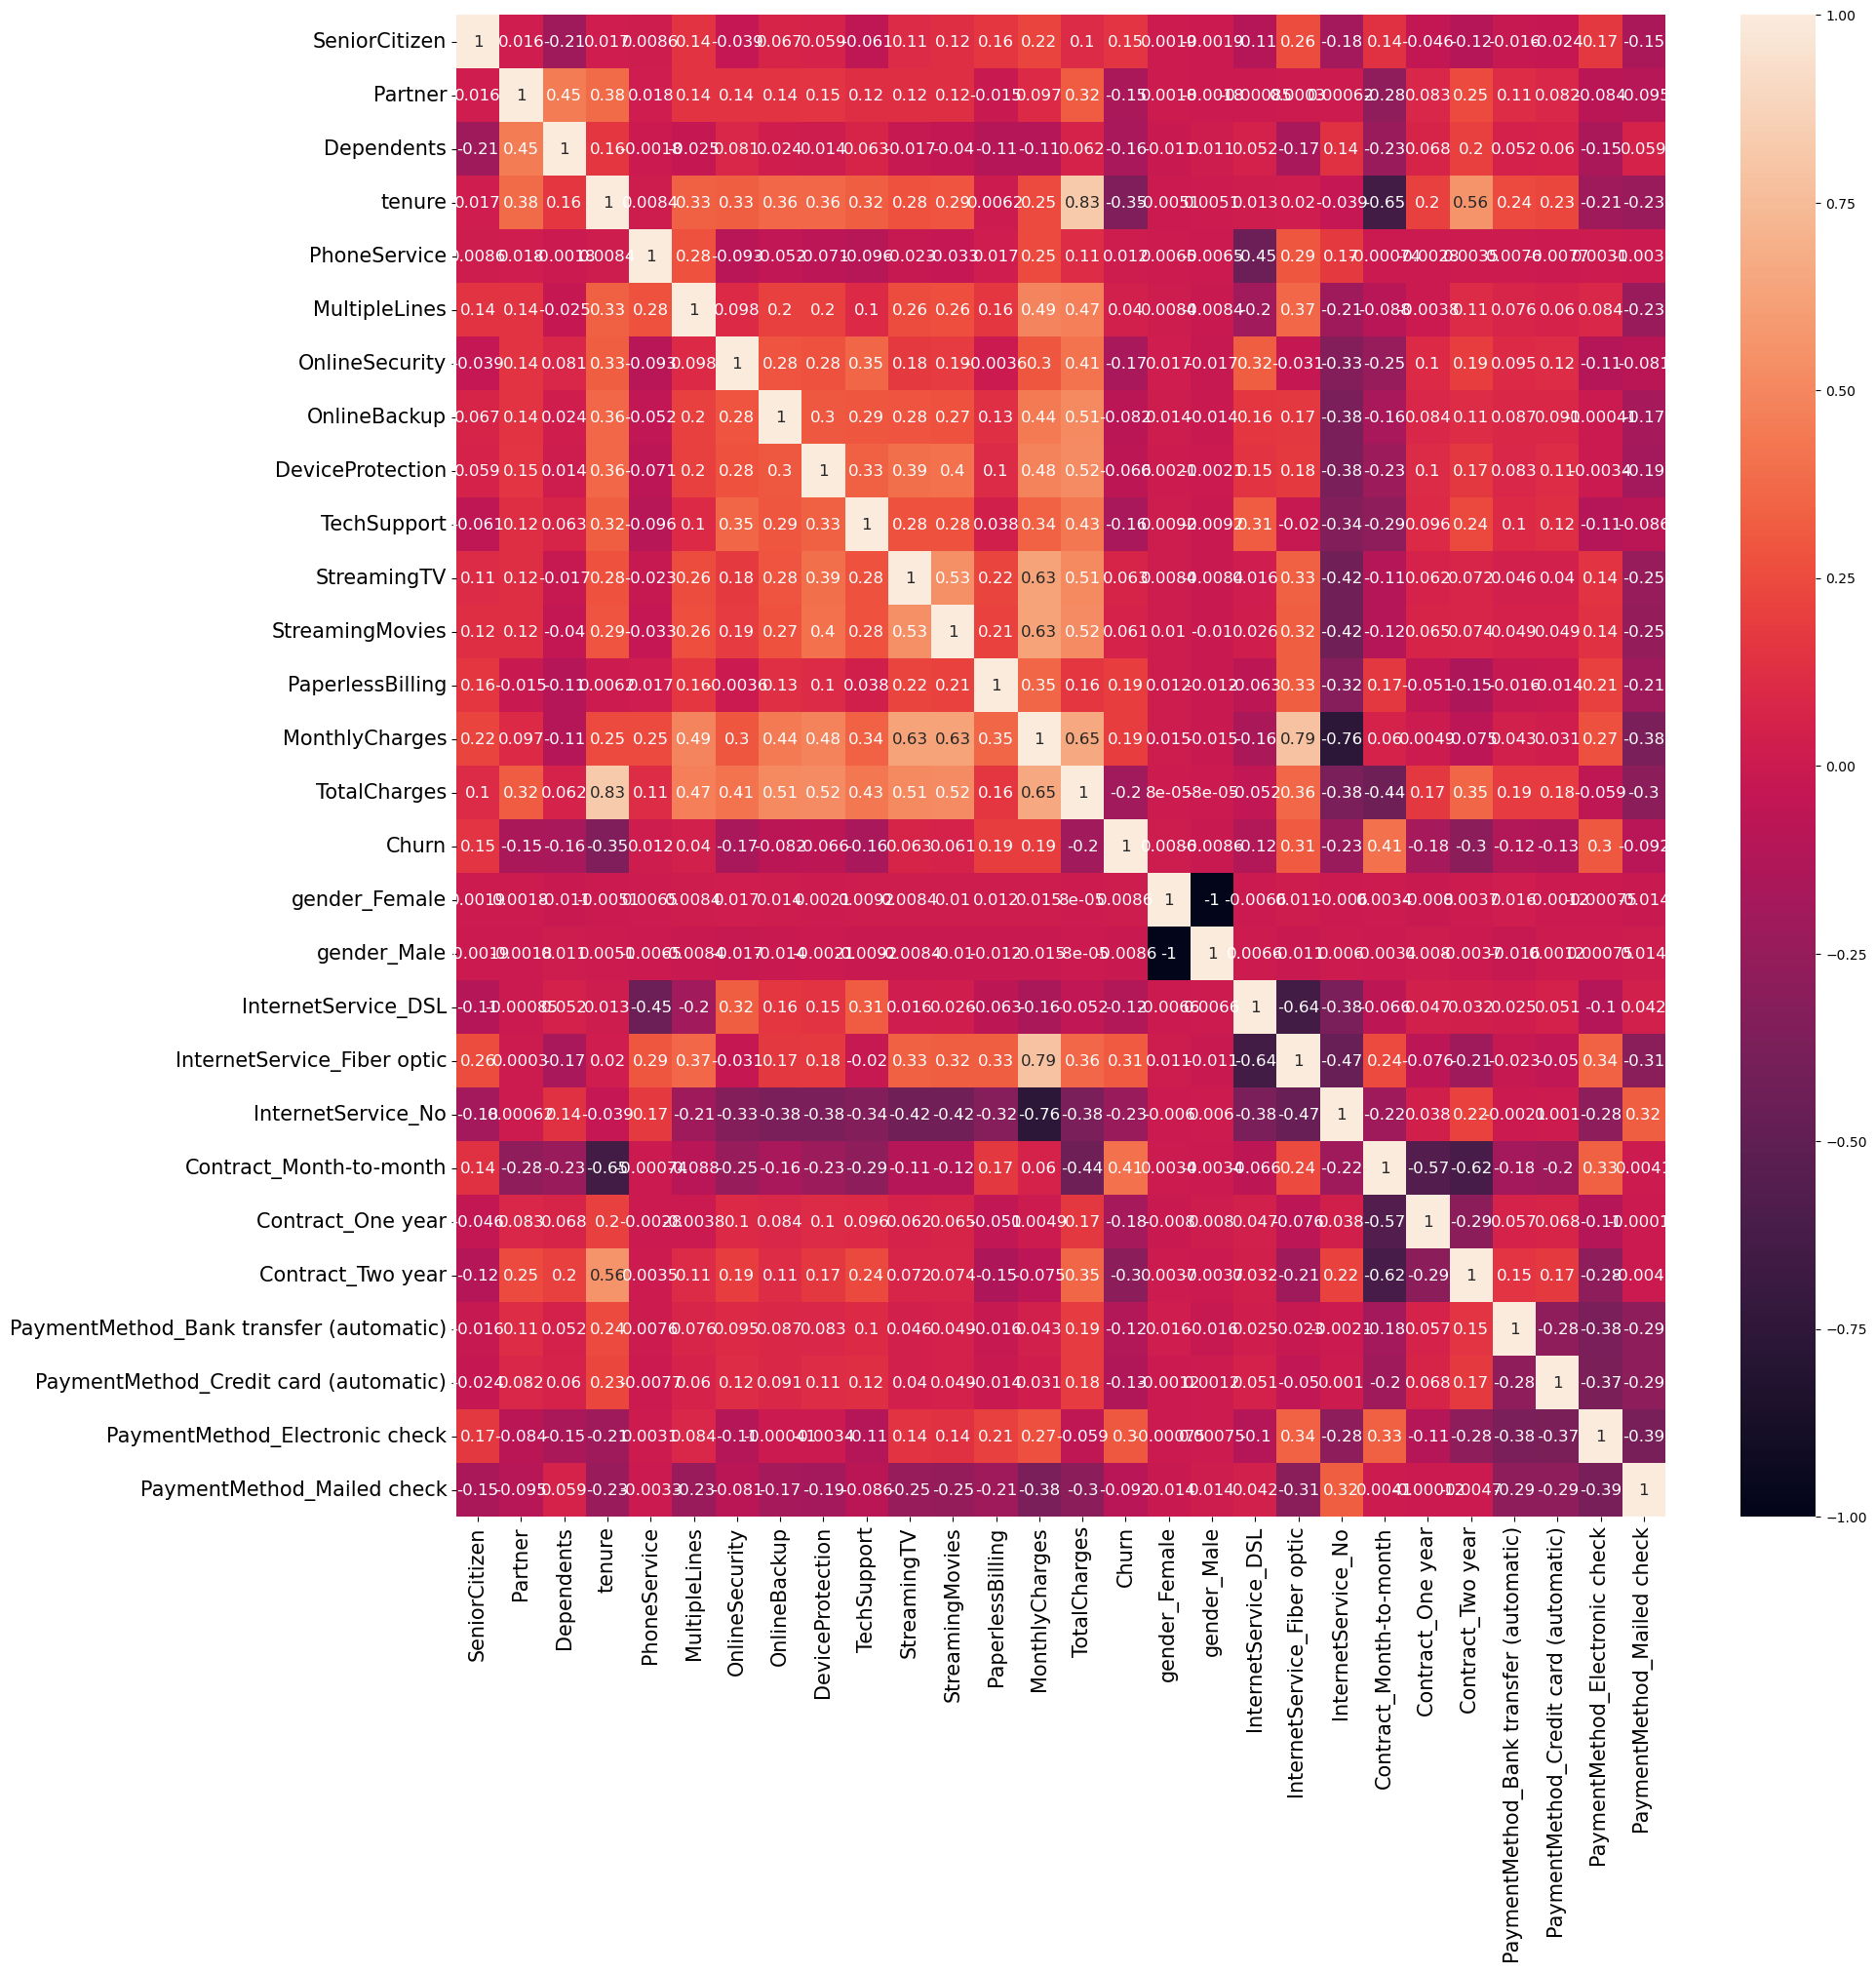

In [194]:
corr = df.corr()
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot = True, annot_kws={'size':12})
heat_map=plt.gcf()
heat_map.set_size_inches(20,20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


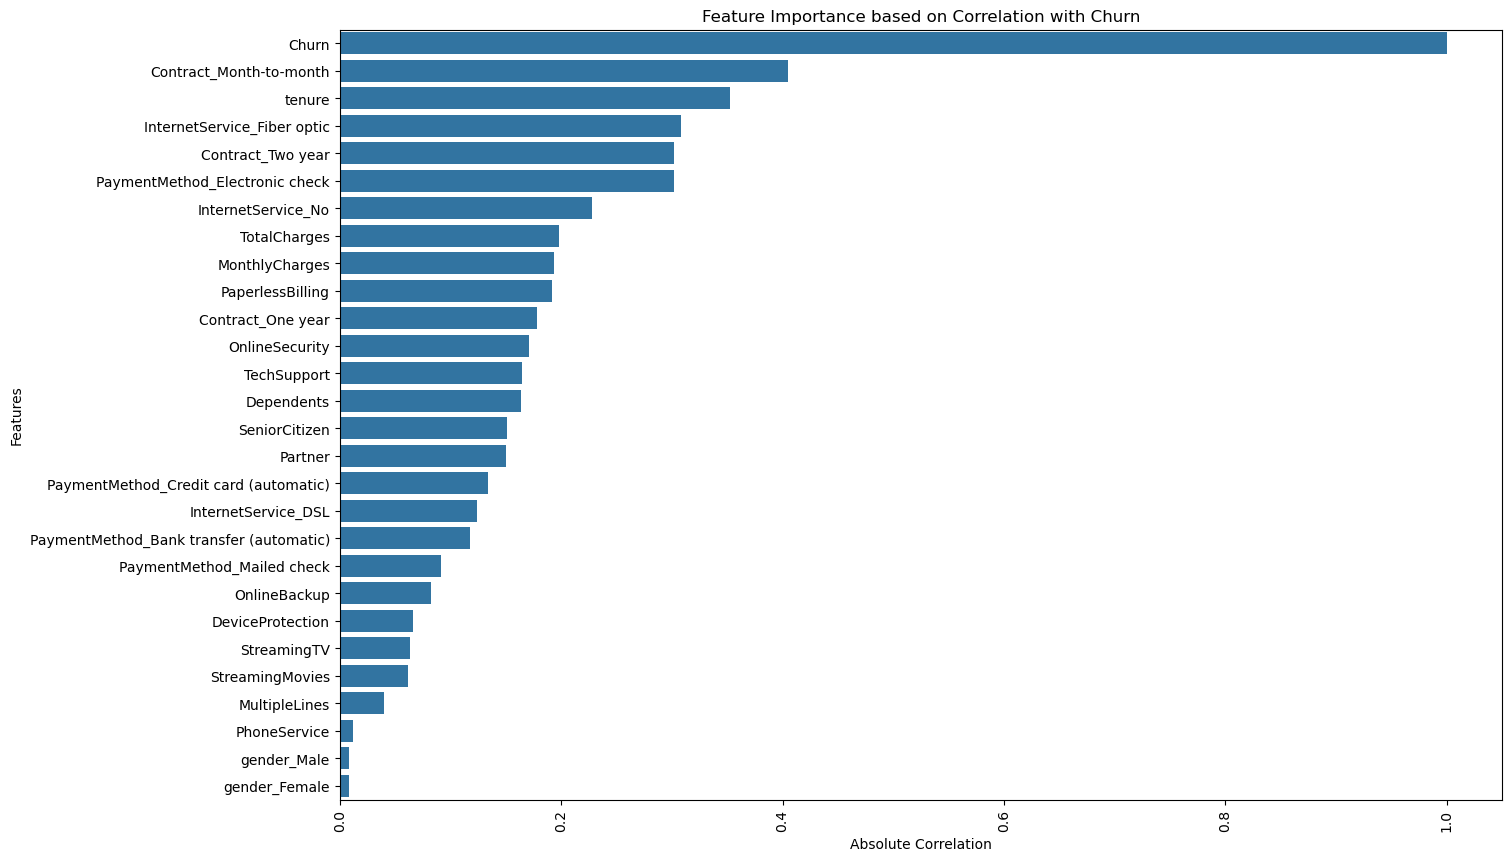

In [195]:
# Importance features with churn

plt.figure(figsize=(15, 10))
sns.barplot(y=corr['Churn'].abs().sort_values(ascending=False).index, x=corr['Churn'].abs().sort_values(ascending=False).values)
plt.title('Feature Importance based on Correlation with Churn')
plt.ylabel('Features')
plt.xlabel('Absolute Correlation')
plt.xticks(rotation=90)
plt.show()



In [197]:
# important features list
important_features = corr['Churn'].abs().sort_values(ascending=False).index[1:11]
print("Important Features:")
print(important_features)





Important Features:
Index(['Contract_Month-to-month', 'tenure', 'InternetService_Fiber optic',
       'Contract_Two year', 'PaymentMethod_Electronic check',
       'InternetService_No', 'TotalCharges', 'MonthlyCharges',
       'PaperlessBilling', 'Contract_One year'],
      dtype='object')


# Train-test split

In [198]:

X = df[important_features]  # --- IGNORE ---
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Scaling

In [199]:
scaler = StandardScaler()   
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Model 1 : Lasso method using for feature selction


In [220]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=1,
        max_iter=5000,
        random_state=42
    ))
])


In [221]:
lasso_model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('log_reg',
                 LogisticRegression(C=1, max_iter=5000, penalty='l1',
                                    random_state=42, solver='saga'))])

In [225]:
coef = lasso_model.named_steps["log_reg"].coef_[0]

feature_names = X_train.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

coef_df


,Feature,Coefficient
0,Contract_Month-to-month,0.396657
1,tenure,-1.241679
2,InternetService_Fiber optic,0.474318
3,Contract_Two year,-0.335655
4,PaymentMethod_Electronic check,0.235113
5,InternetService_No,-0.344750
6,TotalCharges,0.558781
7,MonthlyCharges,-0.078268
8,PaperlessBilling,0.226026
9,Contract_One year,0.000000


In [226]:
selected_features = coef_df[coef_df["Coefficient"] != 0]

selected_features


,Feature,Coefficient
0,Contract_Month-to-month,0.396657
1,tenure,-1.241679
2,InternetService_Fiber optic,0.474318
3,Contract_Two year,-0.335655
4,PaymentMethod_Electronic check,0.235113
5,InternetService_No,-0.344750
6,TotalCharges,0.558781
7,MonthlyCharges,-0.078268
8,PaperlessBilling,0.226026


In [227]:
features_list = selected_features["Feature"].tolist()

features_list


['Contract_Month-to-month',
 'tenure',
 'InternetService_Fiber optic',
 'Contract_Two year',
 'PaymentMethod_Electronic check',
 'InternetService_No',
 'TotalCharges',
 'MonthlyCharges',
 'PaperlessBilling']

In [229]:
X_train_sel = X_train[features_list]
X_test_sel = X_test[features_list]

final_model = LogisticRegression(max_iter=1000, class_weight='balanced')

final_model.fit(X_train_sel, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [230]:
y_pred = final_model.predict(X_test_sel)

y_prob = final_model.predict_proba(X_test_sel)[:, 1]


In [231]:
# evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))    
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.79      1035
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

ROC AUC Score: 0.8348510682270274
Confusion Matrix:
[[730 305]
 [ 75 299]]


* Model is good for churn prediction because recall for churn is high.
* Using Lasso helped reduce features.
* Using class_weight improved minority class detection.

# Model 2 (Logistic regression using SMOTE Method)

In [234]:
#   SMOTE for balancing the dataset and re-evaluate the model


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_sel, y_train)

lr_balanced = LogisticRegression(max_iter=1000, random_state=42)
lr_balanced.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = lr_balanced.predict(X_test_sel)
y_proba_balanced = lr_balanced.predict_proba(X_test_sel)[:, 1]

print("Balanced Dataset Results:")
print(classification_report(y_test, y_pred_balanced))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))




Balanced Dataset Results:
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1035
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409

ROC AUC Score: 0.8324562763181689
Confusion Matrix:
[[692 343]
 [ 66 308]]


| Model                | Accuracy | Recall(1) | Precision(1) | F1(1) | ROC-AUC |
| -------------------- | -------- | --------- | ------------ | ----- | ------- |
| Lasso + class_weight | 0.73     | 0.80      | 0.50         | 0.61  | 0.834   |
| SMOTE                | 0.71     | 0.82      | 0.47         | 0.60  | 0.832   |


* Both models show similar performance, but the balanced model has a slightly higher recall for the positive class (churners), which is important in this context. 
* The AUC score is also slightly improved with SMOTE. The confusion matrix shows that the balanced model correctly identifies more churners (true positives) at the cost of a few more false positives. 

# Model 3 (Random Forest Classifier)

In [245]:
# Random Forest model training

rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)



RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [246]:
# Random Forest Evaluation
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1] 

print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1035
           1       0.56      0.49      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.76      1409

ROC AUC Score: 0.8075860910899274
Confusion Matrix:
[[889 146]
 [190 184]]


* Random Forest classifier was trained on an imbalanced dataset with 1035 samples in class 0 and 374 in class 1.
* Overall model accuracy is 76%, meaning most predictions are correct, but accuracy alone is not enough for imbalanced data.
* Precision for class 0 is 0.82 and recall is 0.86, showing the model predicts the majority class very well.
* Precision for class 1 is 0.56, meaning when the model predicts class 1, it is correct 56% of the time.
* Recall for class 1 is 0.49, indicating the model misses some minority class cases.
* F1-score for class 1 is 0.52, showing moderate performance when balancing precision and recall.
* ROC-AUC score is 0.80, which indicates good ability to distinguish between the two classes.
* Confusion matrix shows 889 true negatives, 184 true positives, 146 false positives, and 190 false negatives.
* Higher false negatives for class 1 explain the lower recall and indicate bias toward the majority class.
* Overall, the model performs well, but minority class detection can be improved using hyperparameter tuning.

# Model 5 (XGBoost Classifier)

In [248]:
#XGBoost model training
xgb_model = xgb.XGBClassifier(n_estimators=1000,random_state=42, scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss',
                              learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8)
xgb_model.fit(X_train_sel, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [249]:
# xgboost evaluation
y_pred_xgb = xgb_model.predict(X_test_sel)
y_proba_xgb = xgb_model.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))





              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.53      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409

ROC AUC Score: 0.8093337466739001
Confusion Matrix:
[[818 217]
 [132 242]]


# Model 6 (XGBoost Classifier with Hyperparameter tuning)

In [254]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2
)

grid_search.fit(X_train_sel, y_train)

print("Best Hyperparameters:", grid_search.best_params_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   0.3s
[CV] END 

In [257]:
best_params = grid_search.best_params_

print(best_params)


{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.6}


In [258]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    random_state=42
)

best_model.fit(X_train_sel, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [259]:
y_pred = best_model.predict(X_test_sel)

y_prob = best_model.predict_proba(X_test_sel)[:, 1]


In [260]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409

ROC AUC Score: 0.842478493373634
Confusion Matrix:
[[932 103]
 [187 187]]


# Pipeline

In [265]:
# create Pipeline for Logistic Regression with SMOTE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr_balanced', LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train_balanced, y_train_balanced)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr_balanced', LogisticRegression(max_iter=1000))])

In [266]:
y_pred = pipeline.predict(X_test_sel)   


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1035
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409



In [268]:
import pickle



feature_names = X_train_balanced.columns.tolist()

with open("feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

with open("lr_smote_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)
    


# Load the pipeline

In [ ]:
with open("lr_smote_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)


# Loaded pipeline for prediction

In [ ]:
y_pred = loaded_pipeline.predict(X_test_sel)
y_prob = loaded_pipeline.predict_proba(X_test_sel)[:, 1]
